<a href="https://colab.research.google.com/github/mohnadmohamed99/optimized-spam-detector/blob/member-4-svm/notebooks/04_svm_evaluation_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. IMPORT LIBRARIES**

In [53]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    make_scorer
)

# **2. LOAD PROCESSED FEATURES**

In [54]:
X_train_vec = joblib.load(
    "../data/processed/X_train_vec.pkl"
)

X_test_vec = joblib.load(
    "../data/processed/X_test_vec.pkl"
)

# **3. LOAD LABELS**

In [55]:
df = pd.read_csv("../data/cleaned_spam.csv")

X = df["message"]
y = df["label"]

_, _, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check that features and labels have matching sizes

print("Training features shape:", X_train_vec.shape)
print("Training labels:", len(y_train))

print("Testing features shape:", X_test_vec.shape)
print("Testing labels:", len(y_test))

assert X_train_vec.shape[0] == len(y_train)
assert X_test_vec.shape[0] == len(y_test)

print("\nData loaded successfully.")

Training features shape: (4135, 7591)
Training labels: 4135
Testing features shape: (1034, 7591)
Testing labels: 1034

Data loaded successfully.


# **4. TRAIN LINEAR SVM**

In [56]:
svm_model = LinearSVC(
    C=1,
    random_state=42
)

svm_model.fit(
    X_train_vec,
    y_train
)

print("\nLinear SVM trained successfully.")


Linear SVM trained successfully.


# **5. MAKE PREDICTIONS**

In [57]:
y_pred_svm = svm_model.predict(
    X_test_vec
)

print(
    "Number of predictions:",
    len(y_pred_svm)
)

Number of predictions: 1034


# **6. CALCULATE SVM METRICS**

In [58]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    pos_label="spam"
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    pos_label="spam"
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    pos_label="spam"
)


print("\n--- Linear SVM Results ---")

print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")


--- Linear SVM Results ---
Accuracy:  0.9845
Precision: 1.0000
Recall:    0.8779
F1-Score:  0.9350


# **7. SVM CONFUSION MATRIX**


SVM Confusion Matrix:
[[903   0]
 [ 16 115]]


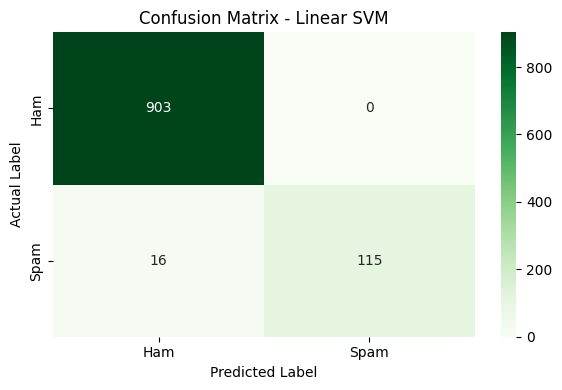

In [59]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["ham", "spam"]
)

print("\nSVM Confusion Matrix:")
print(cm_svm)


plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

# **8. GRID SEARCH CV — SVM OPTIMIZATION**

In [60]:
spam_f1_scorer = make_scorer(
    f1_score,
    pos_label="spam"
)

svm_parameters = {
    "C": [0.01, 0.1, 1, 10]
}

grid_search_svm = GridSearchCV(
    estimator=LinearSVC(
        random_state=42
    ),
    param_grid=svm_parameters,
    scoring=spam_f1_scorer,
    cv=5,
    n_jobs=-1
)

# GridSearch uses Training Data only

grid_search_svm.fit(
    X_train_vec,
    y_train
)


print("\n--- GridSearchCV Results ---")

print(
    "Best Parameters:",
    grid_search_svm.best_params_
)

print(
    "Best Cross-Validation F1:",
    round(
        grid_search_svm.best_score_,
        4
    )
)


--- GridSearchCV Results ---
Best Parameters: {'C': 1}
Best Cross-Validation F1: 0.9239


# **9. EVALUATE THE TUNED SVM ON TEST DATA**

In [61]:
best_svm_model = (
    grid_search_svm.best_estimator_
)

y_pred_tuned_svm = (
    best_svm_model.predict(
        X_test_vec
    )
)


tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_svm
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned_svm,
    pos_label="spam"
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned_svm,
    pos_label="spam"
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned_svm,
    pos_label="spam"
)


print("\n--- Tuned Linear SVM Results ---")

print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1-Score:  {tuned_f1:.4f}")


--- Tuned Linear SVM Results ---
Accuracy:  0.9845
Precision: 1.0000
Recall:    0.8779
F1-Score:  0.9350


# **10. SVM BEFORE AND AFTER OPTIMIZATION**

In [62]:
optimization_comparison = pd.DataFrame({
    "Model": [
        "SVM Before Optimization",
        "SVM After Optimization"
    ],

    "Accuracy": [
        svm_accuracy,
        tuned_accuracy
    ],

    "Precision": [
        svm_precision,
        tuned_precision
    ],

    "Recall": [
        svm_recall,
        tuned_recall
    ],

    "F1-Score": [
        svm_f1,
        tuned_f1
    ]
})


print(
    "\n--- SVM Before and After Optimization ---"
)

display(
    optimization_comparison.round(4)
)


--- SVM Before and After Optimization ---


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Before Optimization,0.9845,1.0,0.8779,0.935
1,SVM After Optimization,0.9845,1.0,0.8779,0.935


# **11. CONFUSION MATRICES FOR MEMBER 3 MODELS**

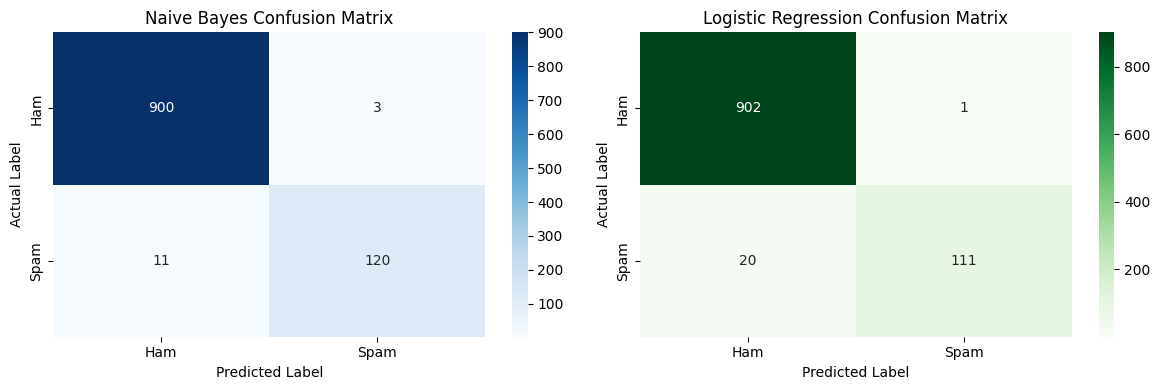

In [63]:
cm_nb = np.array([
    [900, 3],
    [11, 120]
])

cm_lr = np.array([
    [902, 1],
    [20, 111]
])


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)


# Naive Bayes

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"],
    ax=axes[0]
)

axes[0].set_title(
    "Naive Bayes Confusion Matrix"
)

axes[0].set_xlabel(
    "Predicted Label"
)

axes[0].set_ylabel(
    "Actual Label"
)


# Logistic Regression

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"],
    ax=axes[1]
)

axes[1].set_title(
    "Logistic Regression Confusion Matrix"
)

axes[1].set_xlabel(
    "Predicted Label"
)

axes[1].set_ylabel(
    "Actual Label"
)


plt.tight_layout()
plt.show()

# **12. EXPLAIN ALL CONFUSION MATRICES**

In [64]:
tn_nb, fp_nb, fn_nb, tp_nb = (
    cm_nb.ravel()
)

tn_lr, fp_lr, fn_lr, tp_lr = (
    cm_lr.ravel()
)


confusion_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "TN": [
        tn_nb,
        tn_lr,
        tn_svm
    ],

    "FP": [
        fp_nb,
        fp_lr,
        fp_svm
    ],

    "FN": [
        fn_nb,
        fn_lr,
        fn_svm
    ],

    "TP": [
        tp_nb,
        tp_lr,
        tp_svm
    ]
})


print(
    "\n--- Confusion Matrix Comparison ---"
)

display(confusion_results)


--- Confusion Matrix Comparison ---


,Model,TN,FP,FN,TP
0,Naive Bayes,900,3,11,120
1,Logistic Regression,902,1,20,111
2,Linear SVM,903,0,16,115


# **13. COMPARE ALL THREE MODELS**

In [65]:
models_comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy": [
        0.9865,
        0.9797,
        svm_accuracy
    ],

    "Precision": [
        0.9756,
        0.9911,
        svm_precision
    ],

    "Recall": [
        0.9160,
        0.8473,
        svm_recall
    ],

    "F1-Score": [
        0.9449,
        0.9136,
        svm_f1
    ]
})


models_comparison = (
    models_comparison
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n--- Final Model Comparison ---"
)

display(
    models_comparison.round(4)
)


--- Final Model Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9865,0.9756,0.9160,0.9449
1,Linear SVM,0.9845,1.0000,0.8779,0.9350
2,Logistic Regression,0.9797,0.9911,0.8473,0.9136


# **14. SELECT THE BEST MODEL**

In [66]:
best_model_name = (
    models_comparison.loc[0, "Model"]
)

best_f1_score = (
    models_comparison.loc[0, "F1-Score"]
)


print("\n--- Final Decision ---")

print(
    "Best Overall Model:",
    best_model_name
)

print(
    "Best F1-Score:",
    round(best_f1_score, 4)
)


print(
    """
Multinomial Naive Bayes achieved the highest overall
F1-score, Recall, and Accuracy.

Linear SVM achieved the highest Precision of 1.0000,
meaning that it did not classify any Ham message as Spam.

However, SVM missed more Spam messages than Naive Bayes.

Therefore, Multinomial Naive Bayes was selected as the
best overall model because it achieved the strongest
balance between Precision and Recall.
"""
)



--- Final Decision ---
Best Overall Model: Multinomial Naive Bayes
Best F1-Score: 0.9449

Multinomial Naive Bayes achieved the highest overall
F1-score, Recall, and Accuracy.

Linear SVM achieved the highest Precision of 1.0000,
meaning that it did not classify any Ham message as Spam.

However, SVM missed more Spam messages than Naive Bayes.

Therefore, Multinomial Naive Bayes was selected as the
best overall model because it achieved the strongest
balance between Precision and Recall.



# **16. SAVE THE SVM MODELS**

In [67]:
joblib.dump(
    svm_model,
    "../models/linear_svm_model.pkl"
)

joblib.dump(
    best_svm_model,
    "../models/tuned_linear_svm_model.pkl"
)


print(
    "SVM models saved successfully."
)

SVM models saved successfully.
